# Import Python Libraries

In [13]:
import pandas as pd #(data manipulation and preprocessing)
import numpy as np  #(numerical operations)
import matplotlib.pyplot as plt #(data visualization)
import seaborn as sns #(data visualization)

# Create the Data frame

In [14]:
dataframe = pd.read_csv("Zomato data .csv")
print(dataframe.head())

                    name online_order book_table   rate  votes  \
0                  Jalsa          Yes        Yes  4.1/5    775   
1         Spice Elephant          Yes         No  4.1/5    787   
2        San Churro Cafe          Yes         No  3.8/5    918   
3  Addhuri Udupi Bhojana           No         No  3.7/5     88   
4          Grand Village           No         No  3.8/5    166   

   approx_cost(for two people) listed_in(type)  
0                          800          Buffet  
1                          800          Buffet  
2                          800          Buffet  
3                          300          Buffet  
4                          600          Buffet  


In [15]:
dataframe

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet
...,...,...,...,...,...,...,...
143,Melting Melodies,No,No,3.3/5,0,100,Dining
144,New Indraprasta,No,No,3.3/5,0,150,Dining
145,Anna Kuteera,Yes,No,4.0/5,771,450,Dining
146,Darbar,No,No,3.0/5,98,800,Dining


# Convert the datatype of the "rate" column to float and remove the denominator

In [16]:
def handleRate (value):
    value=str(value).split('/')
    value=value[0];
    return float(value)

dataframe['rate']=dataframe['rate'].apply(handleRate)
print(dataframe.head())

                    name online_order book_table  rate  votes  \
0                  Jalsa          Yes        Yes   4.1    775   
1         Spice Elephant          Yes         No   4.1    787   
2        San Churro Cafe          Yes         No   3.8    918   
3  Addhuri Udupi Bhojana           No         No   3.7     88   
4          Grand Village           No         No   3.8    166   

   approx_cost(for two people) listed_in(type)  
0                          800          Buffet  
1                          800          Buffet  
2                          800          Buffet  
3                          300          Buffet  
4                          600          Buffet  


In [17]:
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    object 
 1   online_order                 148 non-null    object 
 2   book_table                   148 non-null    object 
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 8.2+ KB


## (Conclusion: There is no NULL value in dataframe)

# 1. What type of restaurant do the majority of customers order from? 

Text(0.5, 0, 'Type of Restaurant')

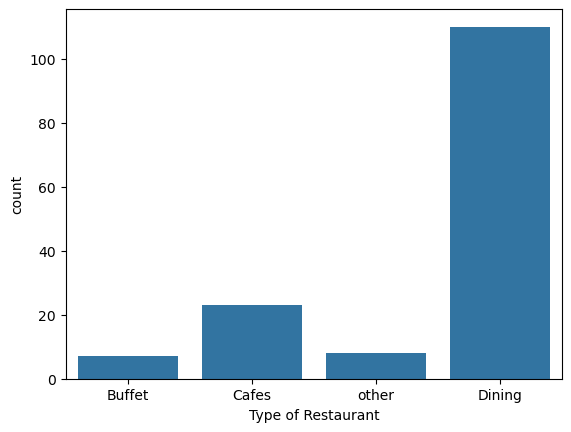

In [18]:
sns.countplot(x=dataframe['listed_in(type)'])
plt.xlabel('Type of Restaurant')

## (The majority of the restaurants fall into the dining category)

# 2. How many votes has each type of restaurant received from customers?

Text(0, 0.5, 'Votes')

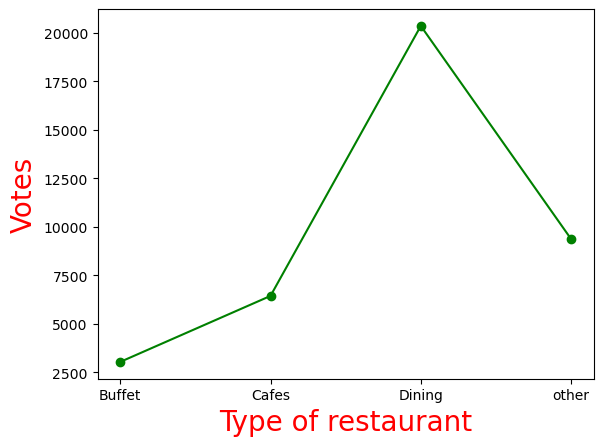

In [27]:
group_by=dataframe.groupby('listed_in(type)')['votes'].sum()
result=pd.DataFrame(group_by)
plt.plot(result, c='g', marker='o')
plt.xlabel('Type of restaurant', c='r', size=20)
plt.ylabel('Votes', c='r', size=20)

## (The restaurant receives majority of votes)

# 3. What are the ratings that the majority of restaurants have received?

[]

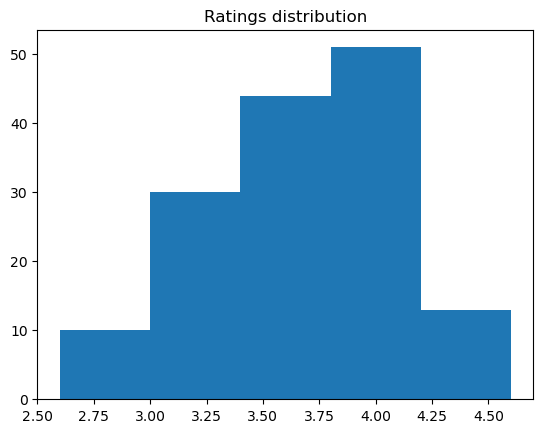

In [32]:
plt.hist(dataframe['rate'], bins=5)
plt.title('Ratings distribution')
plt.plot()

## (The majority of restaurants received ratings ranging from 3.5 to 4)

# 4. Zomato has observed that most couples order most of their food online. What is their average spending on each order?

In [34]:
dataframe.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


[]

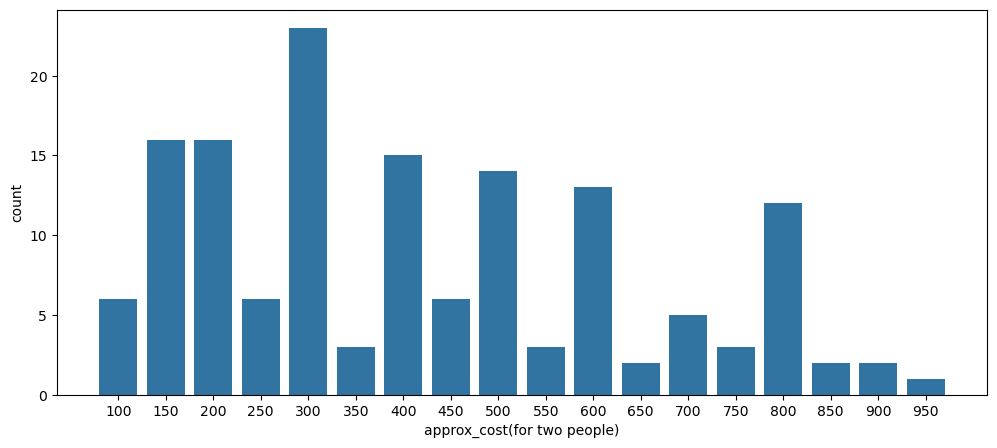

In [45]:
plt.figure(figsize=(12,5))
sns.countplot(x=dataframe['approx_cost(for two people)'])
plt.plot()

## (Average spending is 300)

# 5. Which mode (online or offline) has received the maximum rating?

[]

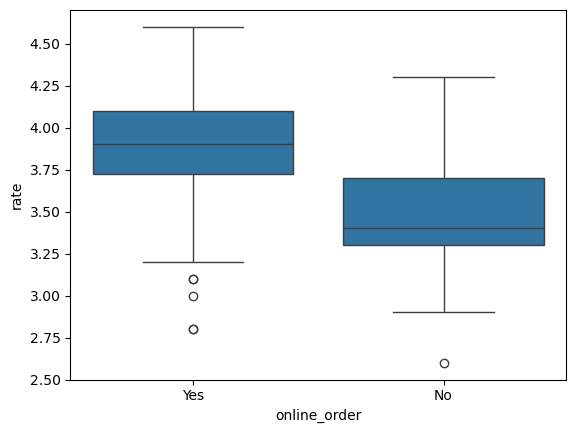

In [47]:
sns.boxplot(x='online_order', y='rate', data=dataframe)
plt.plot()

## (Online order received more ratings than offline)

# 6. Which type of restaurant received more offline orders, so that Zomato can provide those customers with some good offers?

In [49]:
dataframe.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


[]

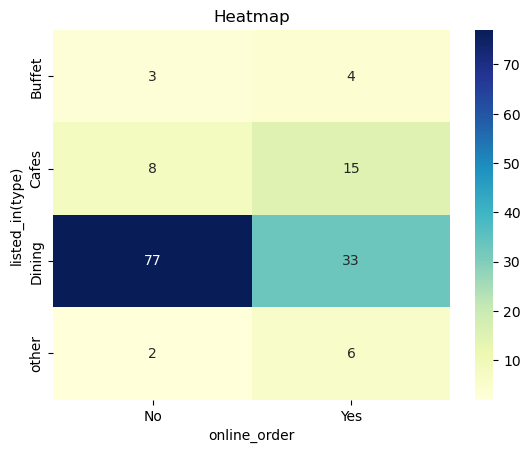

In [53]:
pivot_table=dataframe.pivot_table(index='listed_in(type)', columns='online_order', values='rate', aggfunc='count')
sns.heatmap(pivot_table, annot=True, cmap="YlGnBu", fmt='d')
plt.title('Heatmap')
plt.xlabel('online_order')
plt.ylabel('listed_in(type)')
plt.plot()

## (Dining received more offline orders)